# Análise de Gargalos Logísticos com Descoberta de Subgrupos
## Etapa 1 e 2: Carregamento, Limpeza e Pré-processamento

**Disciplina:** Aprendizado Descritivo (DCC831)  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist   
**Alunos:** Guilherme Salles, Arthur Pereira, Lívia Castro, Davi Sakamoto

---

### Objetivo desta etapa
- Carregar e cruzar as tabelas relevantes do dataset Olist
- Tratar valores ausentes e inconsistências
- Criar a variável-alvo atraso na entrega
- Criar e discretizar features para uso na descoberta de subgrupos

## 1. Carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = './data/'

# Carregamento das tabelas principais
orders    = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items     = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products  = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
sellers   = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')

print('Shapes carregados:')
for name, df in [('orders', orders), ('items', items), ('products', products),
                 ('sellers', sellers), ('customers', customers)]:
    print(f'  {name}: {df.shape}')

Shapes carregados:
  orders: (99441, 8)
  items: (112650, 7)
  products: (32951, 9)
  sellers: (3095, 4)
  customers: (99441, 5)


## 2. Limpeza da tabela de pedidos

Mantemos apenas pedidos com status `delivered` (entregues), pois são os únicos que possuem data real de entrega para calcular o atraso.

In [12]:
print('Distribuição de status dos pedidos:')
print(orders['order_status'].value_counts())

# Filtrando apenas os pedidos que foram entregues
orders = orders[orders['order_status'] == 'delivered'].copy()
print(f'\nPedidos entregues: {len(orders)}')

Distribuição de status dos pedidos:
order_status
delivered    96470
Name: count, dtype: int64

Pedidos entregues: 96470


In [3]:
# Converter colunas de data para datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Verificar nulos nas colunas essenciais
essential = ['order_delivered_customer_date', 'order_estimated_delivery_date']
print('Nulos nas colunas essenciais:')
print(orders[essential].isnull().sum())

# Remover linhas sem data real de entrega ou sem data estimada
before = len(orders)
orders = orders.dropna(subset=essential)
print(f'\nLinhas removidas por nulos nas datas: {before - len(orders)}')
print(f'Pedidos restantes: {len(orders)}')

Nulos nas colunas essenciais:
order_delivered_customer_date    8
order_estimated_delivery_date    0
dtype: int64

Linhas removidas por nulos nas datas: 8
Pedidos restantes: 96470


## 3. Criação da variável-alvo: atraso na entrega

Distribuição da variável-alvo:
atrasado
0    89936
1     6534
Name: count, dtype: int64

Taxa de atraso: 6.8%


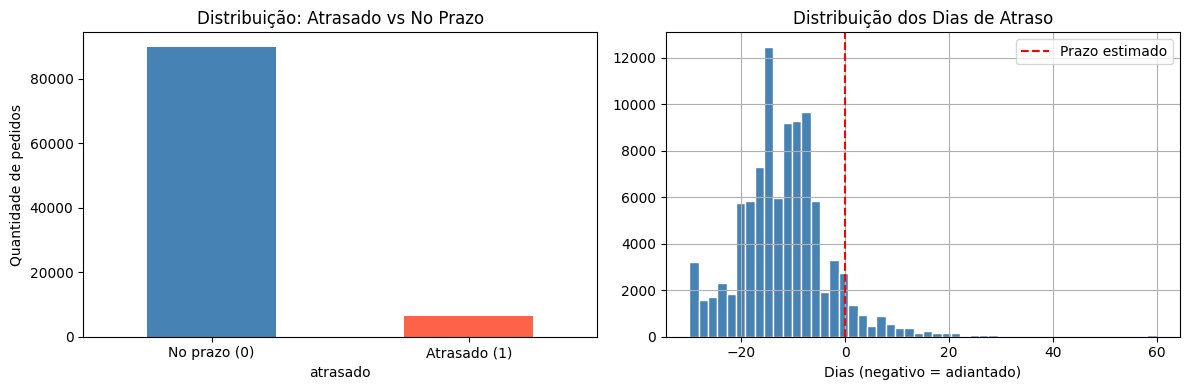

In [13]:
# Calcular atraso em dias (positivo = atrasado, negativo = adiantado)
orders['atraso_dias'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# Variável alvo binária: 1 = atrasado, 0 = no prazo ou adiantado
orders['atrasado'] = (orders['atraso_dias'] > 0).astype(int)

print('Distribuição da variável-alvo:')
print(orders['atrasado'].value_counts())
print(f'\nTaxa de atraso: {orders["atrasado"].mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orders['atrasado'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_xticklabels(['No prazo (0)', 'Atrasado (1)'], rotation=0)
axes[0].set_title('Distribuição: Atrasado vs No Prazo')
axes[0].set_ylabel('Quantidade de pedidos')

orders['atraso_dias'].clip(-30, 60).hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Prazo estimado')
axes[1].set_title('Distribuição dos Dias de Atraso')
axes[1].set_xlabel('Dias (negativo = adiantado)')
axes[1].legend()

plt.tight_layout()
plt.savefig('./data/dist_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Joins entre tabelas

Cruzamos os pedidos com itens, produtos, vendedores e clientes para construir o dataset analítico.

In [5]:
# Agregar itens por pedido:
# - frete médio, preço médio, volume total, quantidade de itens
items_agg = items.groupby('order_id').agg(
    frete_medio        = ('freight_value', 'mean'),
    preco_medio        = ('price', 'mean'),
    n_itens            = ('order_item_id', 'count'),
    seller_id          = ('seller_id', 'first'),   # vendedor principal do pedido
    product_id         = ('product_id', 'first')   # produto principal do pedido
).reset_index()

# Unir pedidos com itens
df = orders[['order_id', 'customer_id', 'atraso_dias', 'atrasado',
             'order_purchase_timestamp']].merge(items_agg, on='order_id', how='inner')

# Unir com clientes (para estado de destino)
df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Unir com vendedores (para estado de origem)
df = df.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

# Unir com produtos (para dimensões físicas)
product_cols = ['product_id', 'product_category_name',
                'product_weight_g', 'product_length_cm',
                'product_height_cm', 'product_width_cm']
df = df.merge(products[product_cols], on='product_id', how='left')

print(f'Dataset após joins: {df.shape}')
df.head(3)

Dataset após joins: (96470, 17)


,order_id,customer_id,atraso_dias,atrasado,order_purchase_timestamp,frete_medio,preco_medio,n_itens,seller_id,product_id,customer_state,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,-8,0,2017-10-02 10:56:33,8.72,29.99,1,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,SP,SP,utilidades_domesticas,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,-6,0,2018-07-24 20:41:37,22.76,118.70,1,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,BA,SP,perfumaria,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,-18,0,2018-08-08 08:38:49,19.22,159.90,1,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,GO,SP,automotivo,420.0,24.0,19.0,21.0


## 5. Limpeza pós-join e engenharia de features

In [6]:
print('Nulos por coluna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos por coluna:
product_category_name    1359
product_weight_g           16
product_length_cm          16
product_height_cm          16
product_width_cm           16
dtype: int64


In [7]:
# Calcular volume do produto em cm³
df['volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

# Preencher mediana para dimensões físicas ausentes
for col in ['product_weight_g', 'volume_cm3']:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# Preencher 'desconhecido' para categóricas ausentes
for col in ['product_category_name', 'customer_state', 'seller_state']:
    df[col] = df[col].fillna('desconhecido')

# Criar flag: rota interestadual (origem ≠ destino)
df['interestadual'] = (df['seller_state'] != df['customer_state']).astype(int)

# Mês da compra (sazonalidade)
df['mes_compra'] = df['order_purchase_timestamp'].dt.month

print('Nulos restantes após limpeza:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nNenhum!' if df.isnull().sum().sum() == 0 else '')

Nulos restantes após limpeza:
product_length_cm    16
product_height_cm    16
product_width_cm     16
dtype: int64



## 6. Discretização de variáveis numéricas

A descoberta de subgrupos com `pysubgroup` exige que variáveis numéricas contínuas sejam convertidas em categorias (discretização). Usamos quartis para isso.

In [8]:
# Discretizar em quartis com labels descritivos
def discretizar_quartis(series, nome):
    return pd.qcut(series, q=4,
                   labels=[f'{nome}_baixo', f'{nome}_medio_baixo',
                           f'{nome}_medio_alto', f'{nome}_alto'],
                   duplicates='drop')

df['peso_cat']    = discretizar_quartis(df['product_weight_g'], 'peso')
df['volume_cat']  = discretizar_quartis(df['volume_cm3'],       'volume')
df['frete_cat']   = discretizar_quartis(df['frete_medio'],      'frete')
df['preco_cat']   = discretizar_quartis(df['preco_medio'],      'preco')

# Converter para string (necessário para pysubgroup)
for col in ['peso_cat', 'volume_cat', 'frete_cat', 'preco_cat']:
    df[col] = df[col].astype(str)

print('Novas colunas categóricas criadas com sucesso.')
df[['peso_cat', 'volume_cat', 'frete_cat', 'preco_cat']].head(3)

Novas colunas categóricas criadas com sucesso.


,peso_cat,volume_cat,frete_cat,preco_cat
0,peso_medio_baixo,volume_baixo,frete_baixo,preco_baixo
1,peso_medio_baixo,volume_medio_baixo,frete_alto,preco_medio_alto
2,peso_medio_baixo,volume_medio_alto,frete_medio_alto,preco_alto


## 7. Seleção das colunas finais e exportação

In [16]:
# Colunas que serão usadas na descoberta de subgrupos
features = [
    # Variável-alvo
    'atrasado',
    # Features geográficas
    'customer_state',
    'seller_state',
    'interestadual',
    # Features do produto
    'peso_cat',
    'volume_cat',
    'product_category_name',
    # Features financeiras
    'frete_cat',
    'preco_cat',
    # Sazonalidade
    'mes_compra',
]

df_final = df[features].copy()

df_final['interestadual'] = df_final['interestadual'].map({0: 'intraestadual', 1: 'interestadual'})
df_final['mes_compra']    = df_final['mes_compra'].astype(str)

print(f'Shape final: {df_final.shape}')
print(f'\nTipos das colunas:')
print(df_final.dtypes)

df_final.to_csv('./data/olist_preprocessado.csv', index=False)
print('\nDataset exportado: ./data/olist_preprocessado.csv')

Shape final: (96470, 10)

Tipos das colunas:
atrasado                 int64
customer_state             str
seller_state               str
interestadual              str
peso_cat                   str
volume_cat                 str
product_category_name      str
frete_cat                  str
preco_cat                  str
mes_compra                 str
dtype: object

Dataset exportado: ./data/olist_preprocessado.csv


## 8. Resumo exploratório rápido

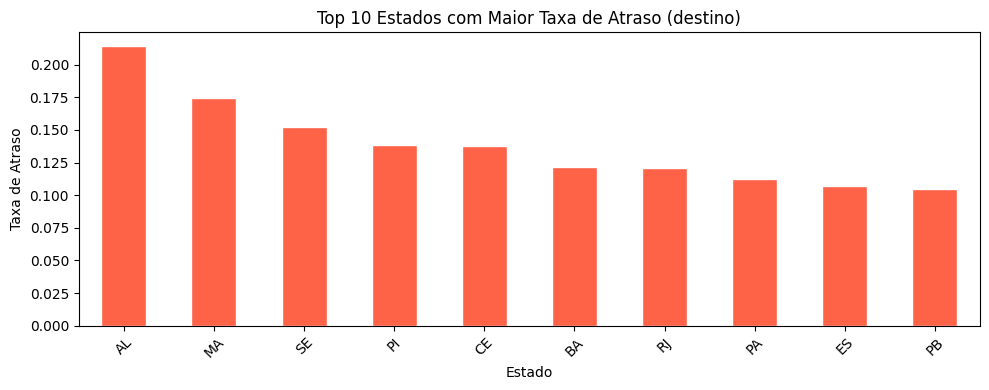

                taxa_atraso  n_pedidos
customer_state                        
AL                 0.214106        397
MA                 0.174338        717
SE                 0.152239        335
PI                 0.138655        476
CE                 0.137608       1279
BA                 0.121622       3256
RJ                 0.121053      12350
PA                 0.112051        946
ES                 0.107268       1995
PB                 0.104449        517


In [10]:
# Taxa de atraso por estado de destino (top 10 piores)
atraso_estado = (
    df.groupby('customer_state')['atrasado']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'taxa_atraso', 'count': 'n_pedidos'})
    .query('n_pedidos >= 100')          # somente estados com volume representativo
    .sort_values('taxa_atraso', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 4))
atraso_estado['taxa_atraso'].plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 10 Estados com Maior Taxa de Atraso (destino)')
plt.ylabel('Taxa de Atraso')
plt.xlabel('Estado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./data/atraso_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()

print(atraso_estado)

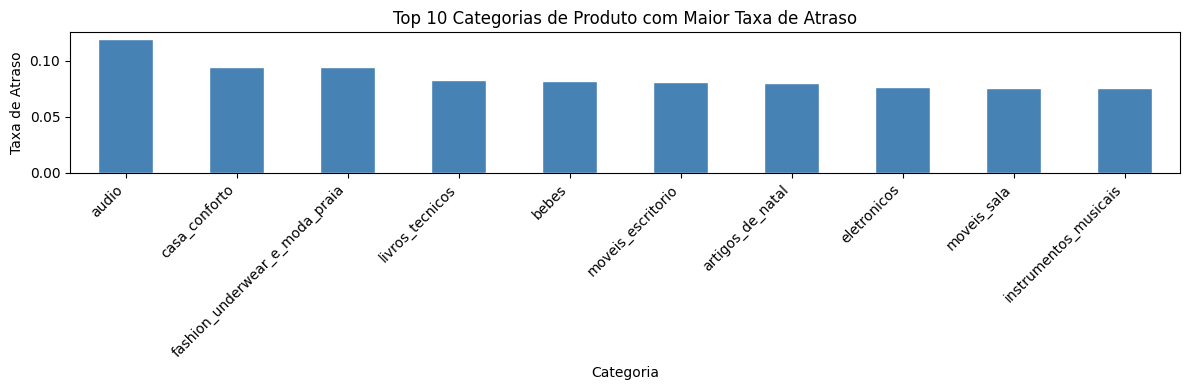

                                taxa_atraso  n_pedidos
product_category_name                                 
audio                              0.119186        344
casa_conforto                      0.094595        370
fashion_underwear_e_moda_praia     0.094017        117
livros_tecnicos                    0.082353        255
bebes                              0.081795       2763
moveis_escritorio                  0.081059       1246
artigos_de_natal                   0.080000        125
eletronicos                        0.076586       2507
moveis_sala                        0.075795        409
instrumentos_musicais              0.075783        607


In [11]:
# Taxa de atraso por categoria de produto (top 10)
atraso_cat = (
    df.groupby('product_category_name')['atrasado']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'taxa_atraso', 'count': 'n_pedidos'})
    .query('n_pedidos >= 50')
    .sort_values('taxa_atraso', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 4))
atraso_cat['taxa_atraso'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Categorias de Produto com Maior Taxa de Atraso')
plt.ylabel('Taxa de Atraso')
plt.xlabel('Categoria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./data/atraso_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

print(atraso_cat)